<a href="https://colab.research.google.com/github/Salina2060/AI_Assignment_1/blob/main/2407800_Salina_Pudasaini_Worksheet1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name: Salina Pudasaini**

**Student Id: 2407800**


**WORKSHEET-1**

**Getting Started with Image Processing with Python.**

**Exercise- 1:**

**1. Read and display the image.**

• Read the image using the Pillow library and display it.

• You can also use matplotlib to display the image

In [1]:
!pip install pillow

In [16]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [28]:
colored_image = Image.open("/content/drive/MyDrive/AI and MachineLearning/car_image.jpg")

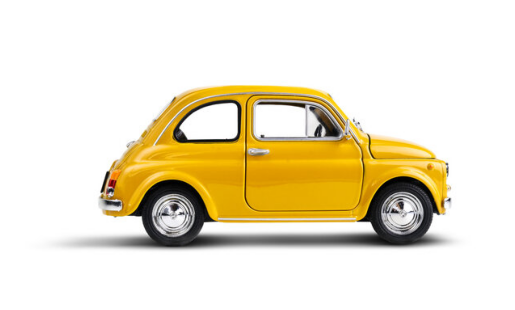

In [14]:
plt.imshow(colored_image)
plt.axis('off')
plt.show()

 Display only the top left corner of 100x100 pixels.

• Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and
Array Indexing

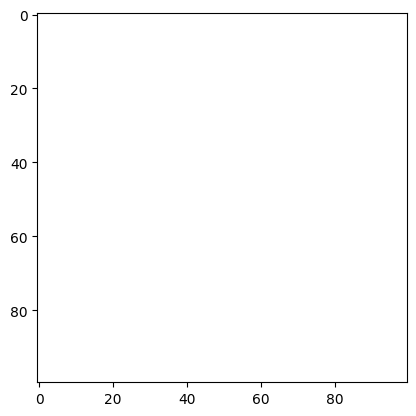

In [20]:
img_array = np.array(colored_image)

# Extract the top-left corner (Rows 0 to 100, Columns 0 to 100)
# Syntax: array[height_start:height_end, width_start:width_end]
top_left = img_array[0:100, 0:100]

plt.imshow(top_left)
plt.show()

3. Show the three color channels (R, G, B).

• Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.}

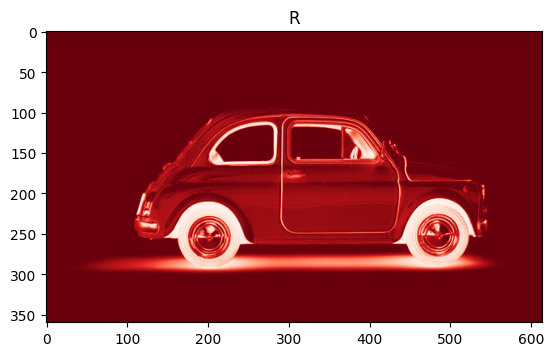

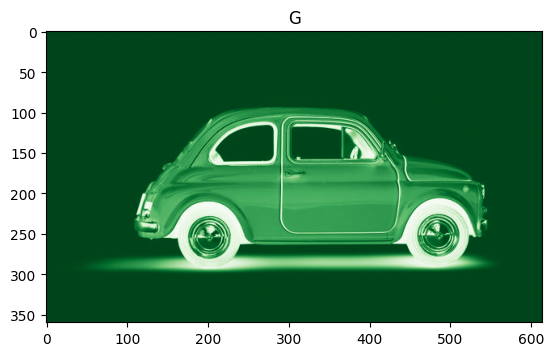

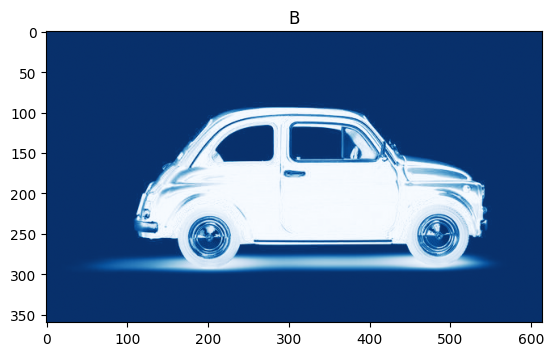

In [22]:
img_array = np.array(colored_image)

#Extract each channel using NumPy slicing [rows, columns, channel]
# The ":" means "take everything" in that dimension
R = img_array[:, :, 0]  # Red channel
G = img_array[:, :, 1]  # Green channel
B = img_array[:, :, 2]  # Blue channel

#Display the Red Channel
plt.imshow(R, cmap='Reds')
plt.title("R")
plt.show()

#Display the Green Channel
plt.imshow(G, cmap='Greens')
plt.title("G")
plt.show()

#Display the Blue Channel
plt.imshow(B, cmap='Blues')
plt.title("B")
plt.show()


 Modify the top 100 ×100 pixels to a value of 210 and display the resulting image:

• Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a
light gray color), and then display the modified image

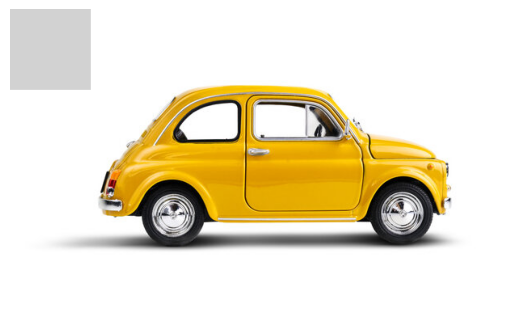

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Creating a copy of the original array so we don't ruin the first one
# img_array was created in the previous tasks
modified_img = img_array.copy()

#modifying the top-left 100x100 area
#This sets R, G, and B all to 210 in that specific square
modified_img[0:100, 0:100] = 210

#display the result
plt.imshow(modified_img)
plt.axis('off')
plt.show()

**Exercise- 2:**

**1. Load and display a grayscale image.**

• Load a grayscale image using the Pillow library.

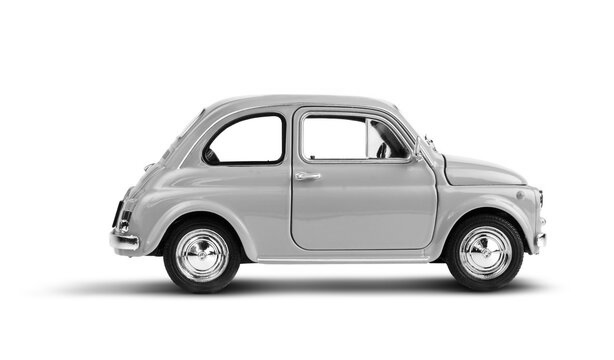

In [29]:
image_grayed = colored_image.convert("L")
display(image_grayed)

• Display the grayscale image using matplotlib.

**2. Extract and display the middle section of the image (150 pixels)**

• Extract a 150 pixel section from the center of the image using NumPy array slicing.

In [31]:
image_array = np.array(image_grayed)
h, w = image_array.shape
center_image = image_array[h//2-75:h//2+75, w//2-75:w//2+75] #[row, column]


• Display this cropped image using matplotlib.

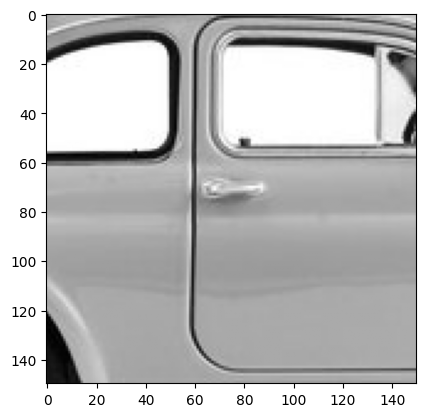

In [32]:
plt.imshow(center_image, cmap='gray')

**3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).**

• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values
above 100 to 255 (creating a binary image).

In [33]:
binary_image = image_array.copy()
binary_image[binary_image < 100] = 0
binary_image[binary_image >= 100] = 255

• Display the resulting binary image.

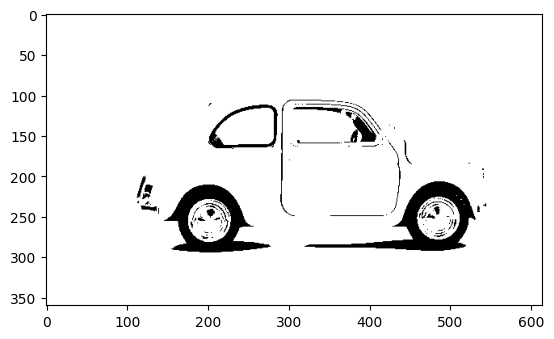

In [34]:
plt.imshow(binary_image, cmap='gray')

**4. Rotate the image 90 degrees clockwise and display the result.**

• Rotatethe image by90degrees clockwise using the Pillow rotate method or by manipulating
the image array.

In [35]:
rotated_image = image_grayed.rotate(-90, expand=True)

• Display the rotated image using matplotlib.

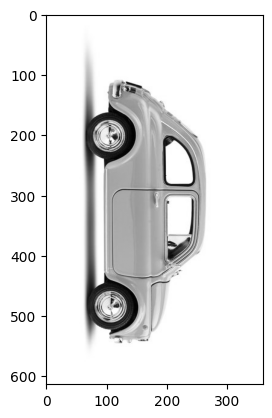

In [36]:
plt.imshow(rotated_image, cmap='gray')

**5. Convert the grayscale image to an RGB image.**

• Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).

In [37]:
rgb_image = np.stack((image_array,)*3, axis=-1)

• Display the converted RGB image using matplotlib.

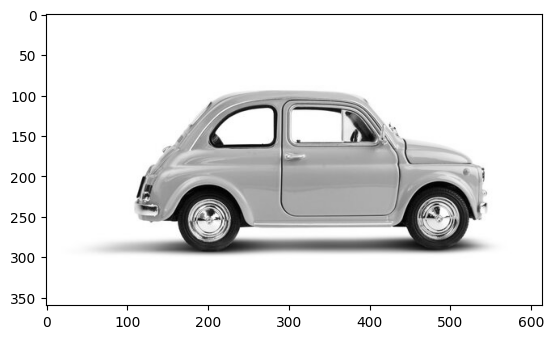

In [38]:
plt.imshow(rgb_image)

**3 Image Compression and Decompression using PCA.**

**1. Load and Prepare Data:**

• Fetch an image of you choice.{If colour convert to grayscale}

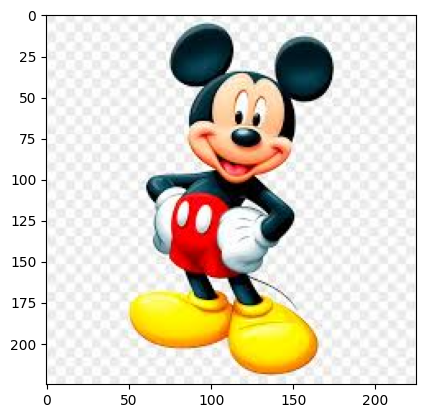

In [40]:
image_colored = Image.open("/content/drive/MyDrive/AI and MachineLearning/image.jpg")
plt.imshow(image_colored)

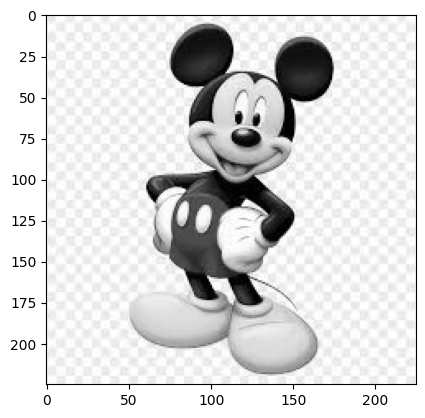

In [41]:
image_grayed = image_colored.convert("L")
plt.imshow(image_grayed, cmap='gray')

In [42]:
array_numpy = np.array(image_grayed, dtype=float)
print(array_numpy.shape)

(225, 225)


• Center the dataset- Standaridze the Data.

In [43]:
centered_dataset = array_numpy - np.mean(array_numpy, axis=0)

• Calculate the covaraince matrix of the Standaridze data.

In [44]:
cov_matrix = np.cov(centered_dataset, rowvar=False)
print(cov_matrix.shape)

(225, 225)


**2. Eigen Decomposition and Identifying Principal Components:**

• Compute Eigen Values and Eigen Vectors.

In [45]:
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)
print("Eigenvalues shape:", eigen_values.shape)
print("Eigenvectors shape:", eigen_vectors.shape)

Eigenvalues shape: (225,)
Eigenvectors shape: (225, 225)


• Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to
the highest eigenvalues.

In [46]:
sorted_indices = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[sorted_indices]
eigen_vectors = eigen_vectors[:, sorted_indices]

• Identify the Principal Components with the help of cumulative Sum plot.

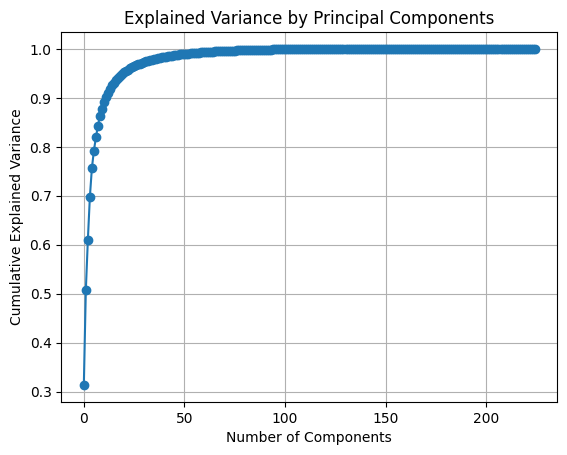

In [47]:
explained_variance = eigen_values / np.sum(eigen_values)
cumulative_variance = np.cumsum(explained_variance)
plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by Principal Components")
plt.grid(True)
plt.show()

In [48]:
k = 50
top_k_eigvecs = eigen_vectors[:, :k]

In [49]:
X_compressed = np.dot(centered_dataset, top_k_eigvecs)

**3. Reconstruction and Experiment:**

• Reconstruction: Transform the original data by multiplying it with the selected eigenvec
tors(PCs) to obtain a lower-dimensional representation.

In [50]:
X_reconstructed = np.dot(X_compressed, top_k_eigvecs.T) + np.mean(array_numpy, axis=0)

• Experiments: Pick Four different combination of principal components with various ex
plained variance value and compare the result.

In [55]:
k_values = [10, 20, 50, 100, 150]
reconstructed_images = []

for k in k_values:
    top_k_eigvecs = eigen_vectors[:, :k]
    X_compressed = np.dot(centered_dataset, top_k_eigvecs)
    X_reconstructed = np.dot(X_compressed, top_k_eigvecs.T) + np.mean(array_numpy, axis=0)
    reconstructed_images.append(X_reconstructed)

• Display the Results and Evaluate.

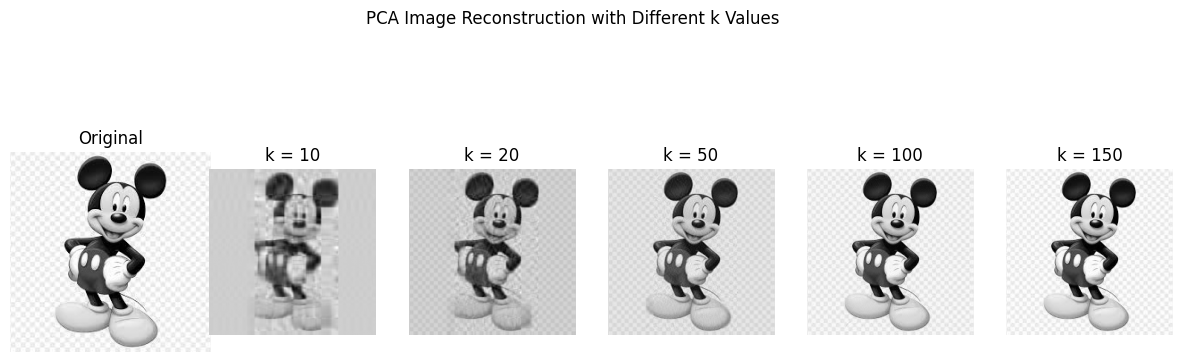

In [56]:
plt.figure(figsize=(15,5))
plt.subplot(1, 5, 1)
plt.imshow(array_numpy, cmap='gray')
plt.title("Original")
plt.axis('off')
for i, X_rec in enumerate(reconstructed_images):
    plt.subplot(1, len(k_values) + 1, i + 2)
    plt.imshow(X_rec, cmap='gray')
    plt.title(f"k = {k_values[i]}")
    plt.axis('off')

plt.suptitle("PCA Image Reconstruction with Different k Values")
plt.show()